<a href="https://colab.research.google.com/github/nushuhu51-ux/TENSORFLOW-FULL-COURSE-FOR-DEEP-LEARNING/blob/main/01_neural_network_regression_with_tensorflow_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Regression with Neural Networks in TensorFlowiy.

There many definitions for a regression problems in our case, we're going to simplify:predicting a numerical variable based on some other combination of variable's, even shorter..predicting a number.

In [ ]:
# import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.20.0


### Creating data to view and fit

(<matplotlib.collections.PathCollection at 0x7ef329b551c0>,)

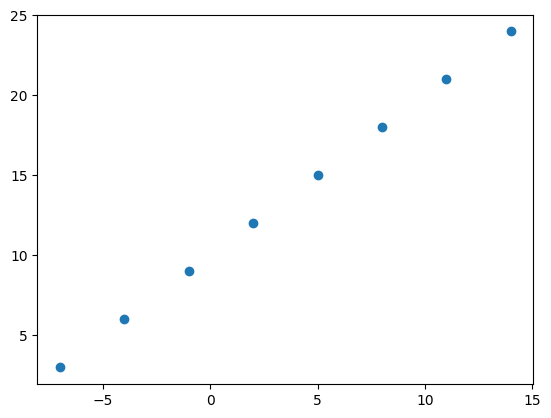

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# create features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0, ])

# create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# visualize
plt.scatter(x, y),

In [ ]:
y == x+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and output shapes

In [ ]:
# create a demo tensor for our housing price prediction problems
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])

house_info, house_price


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

((), ())

In [ ]:
x[0].ndim

0

In [ ]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
# Turn our Numpy array into tensors
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
x, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

(TensorShape([]), TensorShape([]))

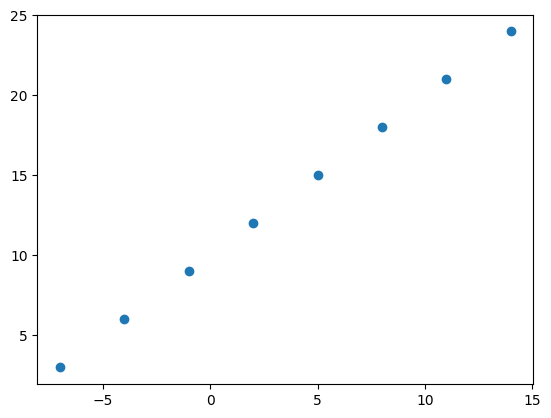

In [ ]:
plt.scatter(x, y)

### steps in modelling with TensorFlow

1. Creating a model - define the input and output layer, as well as the hidden layers of a deep learing model.
2. Compiling a model - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer(tells our model how to improve the patterns its learning) and evaluation metrics(what we can use to interpret the performance of our model).
3. Fitting a model-letting the model try to find patterns between x & y (features and labels)

In [ ]:
x = tf.reshape(x, (-1, 1))

In [ ]:
# 1. Create a model (specified to your problem)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model
model.fit(x, y, epochs=5)

# 4. Evaluate the model
model.evaluate(x, y)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - loss: 10.5835 - mae: 10.5835
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 10.4510 - mae: 10.4510
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.3185 - mae: 10.3185
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 10.1860 - mae: 10.1860
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 10.0535 - mae: 10.0535
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 9.9210 - mae: 9.9210


[9.920988082885742, 9.920988082885742]

In [ ]:
# check out x and y
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# try and make a prediction using our model
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([[17.190914]], dtype=float32)

In [ ]:
y_pred+11

array([[28.190914]], dtype=float32)

### Improving our model

we can improve our model, by altering the steps we took to create a model.

1. **Creating a model** - define the input and output layer, as well as the hidden layers of a deep learing model.
2. **Compiling a model** - here we night fit change the optimization function or perhaps the **learning rate** of the optimization function
3. **Fitting a model** - here we might fit a model for more (give the model more examples to learn from)

In [ ]:
# let's rebuild our model

# 1. create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model.compile(loss=tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # sgd is short for stochasitc dradiant descent
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - loss: 11.4449 - mae: 11.4449
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 11.3124 - mae: 11.3124
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.1799 - mae: 11.1799
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.0474 - mae: 11.0474
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 10.9149 - mae: 10.9149
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 10.7824 - mae: 10.7824
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 10.6499 - mae: 10.6499
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 10.5174 - mae: 10.5174
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 10.3849 - mae: 10.3849
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 10.2524 - mae: 10.2524
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 10.1199 - mae: 10.1199
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 9.9874 - mae: 9.9874
Epoch 13/100
1/1 ━━━━━━

In [ ]:
# Remind ourselfs of the data
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# Let's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


array([[29.852112]], dtype=float32)

In [ ]:
# Let's see if we can make another to improve our model

# 1. create the model(this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss="mae",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step - loss: 13.7759 - mae: 13.7759
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 13.2677 - mae: 13.2677
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 12.7602 - mae: 12.7602
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.2485 - mae: 12.2485
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.7371 - mae: 11.7371
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.2237 - mae: 11.2237
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 10.6935 - mae: 10.6935
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.1385 - mae: 10.1385
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 9.5571 - mae: 9.5571
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8.9455 - mae: 8.9455
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.2936 - mae: 8.2936
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 7.6052 - mae: 7.6052
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━

In [ ]:
# let's remind ourselvs of the data
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# let's try to make a prediction
model.predict(np.array([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


array([[32.705074]], dtype=float32)

### Evaluating a Model

In practice , a typical workflow you will go throgh when building neural networks is:

'''
Build a model -> fit it -> evaluate it -> tweak a model -> fit is -> evaluate is -> tweak a model -> ...

when it comes to evaluation... there are 3 words you should memorize:

> "Visualize, visualize, visualize"
 it is good to visualize:

 * The data- what data are we working with? what does it looks like?
 * the model itself-what does our model looks like?
 * the training of a model-how does a model perform while it learns?
 * the predictions of the model-how to the predictions of a model line up against of the ground truth?

In [ ]:
# make a bigger dataset
x = tf.range(-100, 100, 4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
# make labels for the dataset
y = x+10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

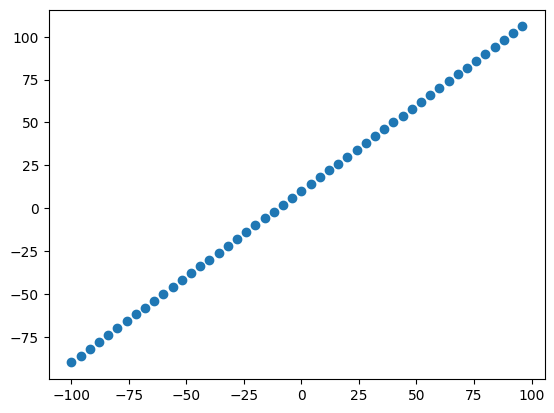

In [ ]:
# visualize the data
import matplotlib.pyplot as plt
plt.scatter(x, y)

### The 3 sets...

* **training set**- the model learns from this data, which is typically 70-80% of the total data you have available.
* **validation set**- the model gets tuned on this data, which is typically 10-15% of the data available.
* **test set** - the model gets evaluated on this data to  test what is has learned, this set is typically 10-15% of the total data available.

In [ ]:
# check the length of how many samples we have
len(x)

50

In [ ]:
# split the data into train and test sets
x_train = x[:40]
y_train = y[:40]


x_test = x[40:]
y_test = y[40:]

len(x_train), len(x_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualizing the data

Now we've got our data in training and testing sets..let's as visualize is again!

(<matplotlib.legend.Legend at 0x7ef333e5ac60>,)

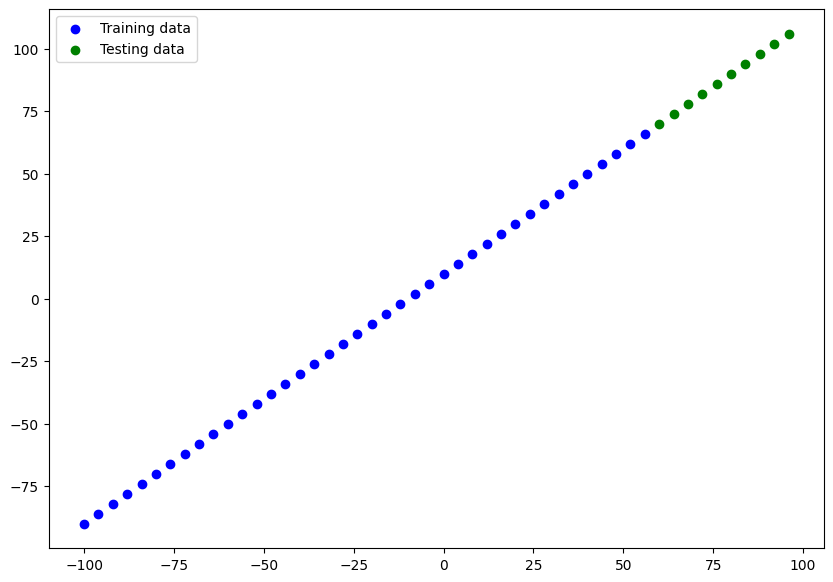

In [ ]:
plt.figure(figsize=(10, 7))
# plot training the data in blue
plt.scatter(x_train, y_train, c="b", label="Training data")
# plot test data in green
plt.scatter(x_test, y_test, c="g", label="Testing data")
# show a legend
plt.legend(),

In [ ]:
# Let's have a look at how to build a neural network for our data
tf.random.set_seed(42)
# 1. create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="Model_one")
# 2. compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. fit the model
model.fit(x_train, y_train, epochs=100)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - loss: 14.7947 - mae: 14.7947
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 26.8581 - mae: 26.8581 
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.4484 - mae: 11.4484
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 14.8291 - mae: 14.8291
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 14.4473 - mae: 14.4473 
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 13.5654 - mae: 13.5654
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 17.3900 - mae: 17.3900
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 10.2675 - mae: 10.2675
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.1531 - mae: 11.1531
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 12.0625 - mae: 12.0625
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 13.0075 - mae: 13.0075 
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.8037 - mae: 15.8037 
Epoch 13/100
2/2 ━━

### Visualizing the model

In [ ]:
model.summary()

Model: "Model_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

* Total params - total number of parameters in the model.
* Trainable params - these are the parameters the model can update as it trains.
* Non-trainable params- these parameters are not updated during training.

In [ ]:
# Let's fit our model to the training data
model.fit(x_train, y_train, epochs=100, verbose=0)

In [ ]:
# Get a summary of our model
model.summary()

Model: "Model_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

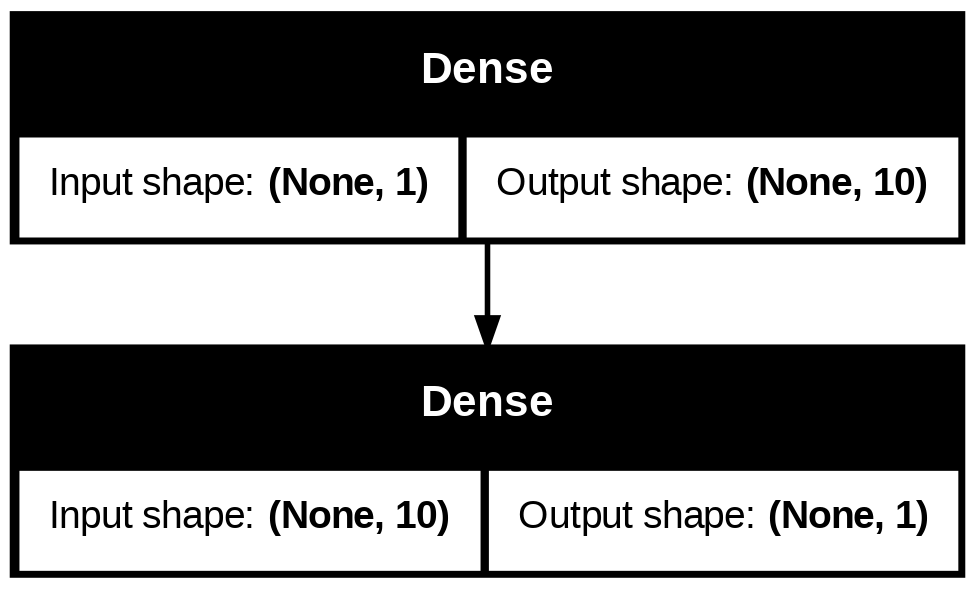

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes=True)

### Visualizing our model's predictions

T ovisualize predictions, it's a good idea to plot them against the ground truth labels.
offeten you'll see this in the form of y_test ot y_true versus y_pred

In [ ]:
# make some predictions
y_preds = model.predict(x_test)
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


array([[38.59973 ],
       [40.952946],
       [43.306164],
       [45.659378],
       [48.012592],
       [50.36581 ],
       [52.719025],
       [55.07224 ],
       [57.425453],
       [59.77866 ]], dtype=float32)

In [ ]:
print(x_test.shape)
print(y_pred.shape)

(10,)
(1, 1)


In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
# let's create a plotting function
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=y_pred):
  """
  plots training data, test data and compares predictions to ground truth labels.
  """
  plt.figure(figsize=(10, 7))
  # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # plot testing data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # plot model's predictions in red
  plt.scatter(test_data, predictions, c="r", label="predictions")
  # show the legend
  plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
(10,)
(10,)


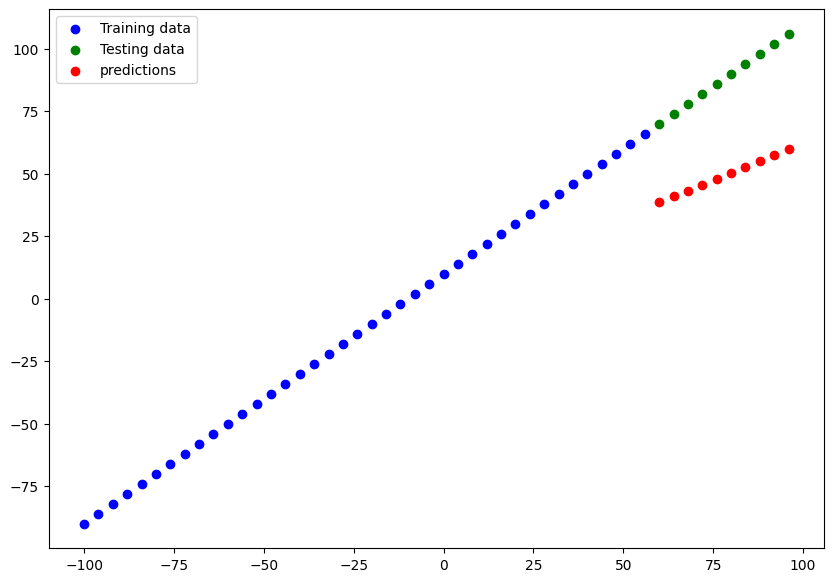

In [ ]:
# Make predictions for ALL test data
y_pred = model.predict(x_test).squeeze()

# Check shapes
print(x_test.shape)
print(y_pred.shape)

# Plot
plot_predictions(
    train_data=x_train,
    train_labels=y_train,
    test_data=x_test,
    test_labels=y_test,
    predictions=y_pred
)

### Evaluating our model's predictions with regression evaluating metrics

Depending on the problem you are working on, there will be different evaluation metrics to evaluate your model's performance.
since we're working on a regression, two of the main metrics:
* MAE- Mean absolute error, "on average, how wrong is each of my model's predictions"
* MSE- mean squared error, "square the average errors"

In [ ]:
# evaluate the model on the test set
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 38.8108 - mae: 38.8108


[38.81079864501953, 38.81079864501953]

In [ ]:
# Create MAE object
mae = tf.keras.losses.MeanAbsoluteError()

# Calculate MAE
result = mae(y_test, y_pred)

# Print result
print(result.numpy())

38.810802


In [ ]:
tf.constant(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([38.59973 , 40.952946, 43.306164, 45.659378, 48.012592, 50.36581 ,
       52.719025, 55.07224 , 57.425453, 59.77866 ], dtype=float32)>

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([38.59973 , 40.952946, 43.306164, 45.659378, 48.012592, 50.36581 ,
       52.719025, 55.07224 , 57.425453, 59.77866 ], dtype=float32)>

In [ ]:
mae = tf.keras.losses.MeanAbsoluteError()(y_test, tf.squeeze(y_pred))

print(mae.numpy())

38.810802


In [ ]:
# Create MSE object
mse = tf.keras.losses.MeanSquaredError()

# Calculate MSE
result = mse(y_test, tf.squeeze(y_pred))

# Print result
print(result.numpy())

1528.6514


In [ ]:
# make some functions to reuse MAE and MSE
def mae(y_true, y_pred):
  return  tf.keras.losses.MeanAbsoluteError()(y_test, tf.squeeze(y_pred))

def mse(y_true, y_pred):
  return tf.keras.losses.MeanSquaredError()(y_test, tf.squeeze(y_pred))


### Running experiments to improve our model

'''
Build a model -> fit it -> evaluate it -> tweak it -> fit it
-> evaluate it -> tweak it -> fit it -> evaluate it ...
'''

1. Get more data - get more examples for your model to train
on (more opportunities to learn patterns or relationships
between features and labels).

2. Make your model larger (using a more complex model) - this
might come in the form of more layers or more hidden units in
each layer.

3. Train for longer - give your model more of a chance to find
patterns in the data.

Let's do 3 modelling experiments:

1. `model_1` - same as the original model, 1 layer
2. model_2 -2layers, traind for 100 epochs
3. model_3 -2layers,traind dor 500 epochs

* **Build model_1**

In [ ]:
# set random seed
tf.random.set_seed(42)
# Reshape data
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# Build model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile model
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Fit model
model_1.fit(x_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - loss: 17.4145 - mae: 17.4145
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.6571 - mae: 11.6571
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.9454 - mae: 7.9454
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 10.8447 - mae: 10.8447
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 7.7041 - mae: 7.7041
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 11.8902 - mae: 11.8902
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.1652 - mae: 8.1652
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 9.8625 - mae: 9.8625
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.1465 - mae: 8.1465
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.8496 - mae: 9.8496
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.1278 - mae: 8.1278
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 9.8367 - mae: 9.8367
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


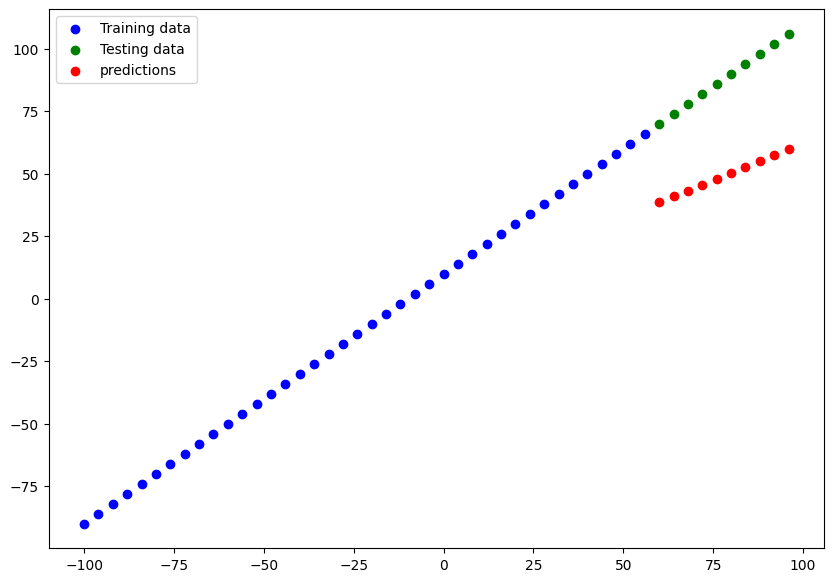

In [ ]:
# make and plot predictions for model_1
y_pred_1 = model_1.predict(x_test)
plot_predictions(predictions=y_pred)

In [ ]:
tf.constant(y_pred_1), tf.squeeze(y_pred_1)

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[ 63.25831 ],
        [ 67.3814  ],
        [ 71.50449 ],
        [ 75.627594],
        [ 79.75069 ],
        [ 83.87379 ],
        [ 87.99688 ],
        [ 92.11997 ],
        [ 96.24307 ],
        [100.366165]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 63.25831 ,  67.3814  ,  71.50449 ,  75.627594,  79.75069 ,
         83.87379 ,  87.99688 ,  92.11997 ,  96.24307 , 100.366165],
       dtype=float32)>)

In [ ]:
# calculate model_1 evaluation metrics
mae_1 = mae(y_test, tf.squeeze(y_pred_1))
mse_1 = mse(y_test, tf.squeeze(y_pred_1))
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=6.1877641677856445>,
 <tf.Tensor: shape=(), dtype=float32, numpy=38.41343307495117>)

### Build model_2

* 2 dense layers, traind for 100 epochs

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mse"])
# 3. fit the model
model_2.fit(x_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 19.8529 - mse: 602.6205
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.9237 - mse: 133.9306
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.2068 - mse: 93.8046
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.9107 - mse: 133.5592
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.1881 - mse: 93.3791
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.8978 - mse: 133.1896
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.1694 - mse: 92.9552
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.8849 - mse: 132.8216
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.3387 - mse: 97.1694
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.8522 - mse: 108.1285
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.7408 - mse: 106.0649
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.4745 - mse: 99.3139
Epoch 13/100
2/2 ━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


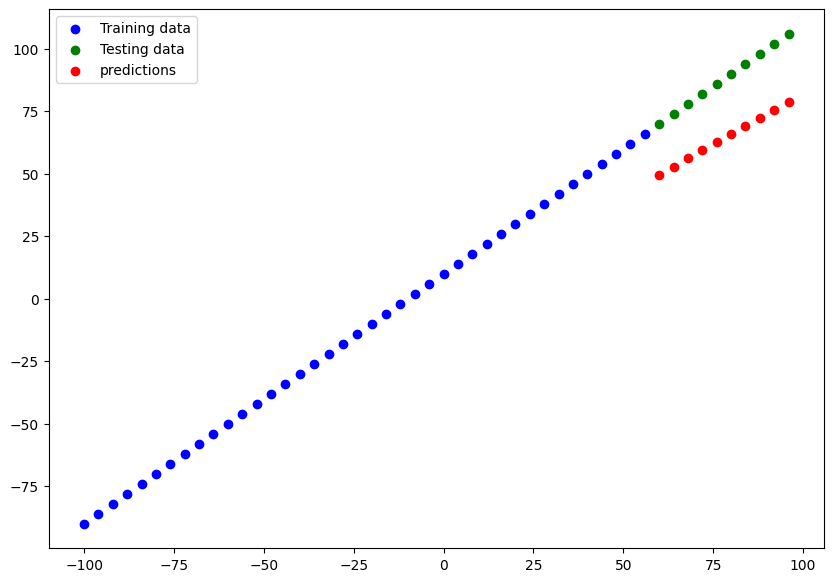

In [ ]:
# make and plot predictions of model_2
y_preds_2 = model_2.predict(x_test)
plot_predictions(predictions=y_preds_2)

In [ ]:
# calculate model_2 evaluation metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=23.834796905517578>,
 <tf.Tensor: shape=(), dtype=float32, numpy=573.1490478515625>)

#### Build model_3

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1. create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mse"])
# 3. fit the model
model_3.fit(x_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 41.7213 - mse: 2526.8628
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 28.0492 - mse: 1089.7800
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 25.0572 - mse: 871.0684 
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 16.4501 - mse: 414.8722
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 18.6616 - mse: 468.6777
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 13.5921 - mse: 288.5390
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15.1786 - mse: 326.9823
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.6514 - mse: 334.6736
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 12.2117 - mse: 242.3267
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.7443 - mse: 307.1545
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15.5423 - mse: 327.0248
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.3052 - mse: 236.7288
Epoch 13/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


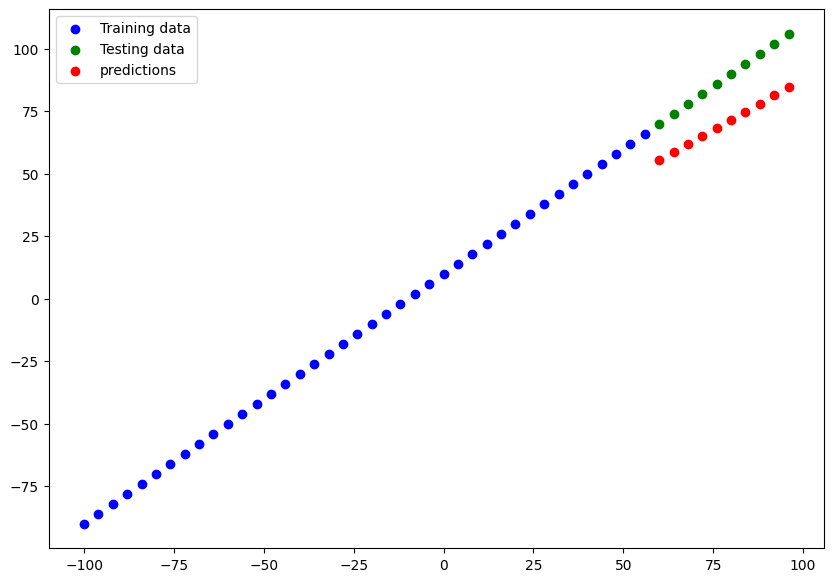

In [ ]:
# make and plot predictions
y_preds_3 = model_3.predict(x_test)
plot_predictions(predictions=y_preds_3)

In [ ]:
# calculate model_3 evaluation metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=18.01967430114746>,
 <tf.Tensor: shape=(), dtype=float32, numpy=329.46002197265625>)

### comparing the results of our experiments

we've run a few experiments,let's compare the results.


In [ ]:
# Let's compare our model's results using a pandas DataFrame
import pandas as pd
model_results = [["model_1", mae_1.numpy(), mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,6.187764,38.413433
1,model_2,23.834797,573.149048
2,model_3,18.019674,329.460022


In [ ]:
model_2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
model_3.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

#### Looks like model_2 performed the best...

model_2.summary()

In [ ]:
model_2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

#### Tracking your experiments

one really good habit in machine learning modelling is to track your results of your experiments.

And when doing so, it can be tedious if you're running lots of experiments.
Luckily, there are tools to help us!

**Resource**: As you build more models, you'll want to look into using:
* TensorBoard - a component of the tensorFlow library to help track modelling experiments (we'll see this one later).
* Weights & Biases - a tool for tracking all of kinds of machine learning experiments (Plugs straight into TensorBoard).

### Saving our models

Saving our models allows us to use them outside of Google colab (or wherever they were trained) such as in a web application or a mobile app.

There are two main  formats we can ave our model's too:
* 1. The SaveMode format
* 2. The HDF5 format

In [248]:
# save model using the save mode format
model_2.save("best_model_savedModel_format.keras")

In [249]:
# save model using the HDF5 format
model_2.save("best_model_HDF5_format.h5")

### Loading in a saved model

In [251]:
# Load the .keras model
loaded_SavedModel_format = tf.keras.models.load_model(
    "/content/best_model_savedModel_format.keras"
)

# Show model summary
loaded_SavedModel_format.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [253]:
model_2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [255]:
# compare model_2_predictions with Saved Model format model predictions
model_2_preds = model_2.predict(x_test)
loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(x_test)
model_2_preds == loaded_SavedModel_format

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [260]:
# load in a model using the .hs format
loaded_h5_model = tf.keras.models.load_model("/content/best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [261]:
# check to see if loaded.h5 model predictions match model_2
model_2_preds = model_2.predict(x_test)
loaded_h5_model_preds = loaded_h5_model.predict(x_test)
model_2_preds == loaded_h5_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [256]:
model_2_preds, loaded_SavedModel_format_preds

(array([[49.686405],
        [52.903915],
        [56.121426],
        [59.338936],
        [62.556446],
        [65.77396 ],
        [68.99147 ],
        [72.20898 ],
        [75.42648 ],
        [78.644   ]], dtype=float32),
 array([[49.686405],
        [52.903915],
        [56.121426],
        [59.338936],
        [62.556446],
        [65.77396 ],
        [68.99147 ],
        [72.20898 ],
        [75.42648 ],
        [78.644   ]], dtype=float32))

In [257]:
mae(y_true=y_test, y_pred=model_2_preds)==mae(y_true=y_test, y_pred=loaded_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>